# Семинар 5. Свой Ньютон и BFGS против SciPy

Весь семинар — за ноутбуком (~30 минут), пакеты — `numpy`, `scipy`, `matplotlib`. Пишем методы лекции сами по формулам конспекта, запускаем на Розенброке и синусе из ДЗ 2 и сверяем каждое число с конспектом и со SciPy. Задачи и рисовальщики берём из [`l5helpers.py`](l5helpers.py) (тот же код, что в демо); методы там тоже есть — но здесь мы пишем их заново и проверяем, что совпало.

| Мин | Часть |
|-----|------|
| 12 | **1. Ньютон**: чистый за десять строк — $7$ итераций; почему `Newton-CG` делает $85$; backtracking — $22$ |
| 18 | **2. BFGS и Гаусс–Ньютон**: секущее уравнение руками (11.5), BFGS с нуля — $34$ против $33$ у SciPy, соревнование стартов, Гаусс–Ньютон на синусе — $7$ против $731$ |

Запуск: `uv run jupyter lab` в корне репозитория.

In [1]:
%matplotlib inline

from l5helpers import *  # задачи (rosen*, sine_*, make_chain), рисовальщики, эталонные методы для сверки

## Часть 1. Метод Ньютона своими руками

**Шаг 1. Чистый Ньютон за десять строк.** Формула одна: $H_kp_k=-g_k$, $x_{k+1}=x_k+p_k$. Останов — по $\lVert\nabla f\rVert\le10^{-10}$. Запускаем на Розенброке из $(-1.2,1)$: в конспекте $7$ итераций и ошибки $2.2,\ 2.21,\ 4.18,\ 0.48,\ 0.056,\ 9.6\cdot10^{-6},\ 1.9\cdot10^{-11}$.

In [2]:
def my_newton(grad, hess, x0, tol=1e-10, maxit=50):
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        p = np.linalg.solve(hess(x), -g)       # шаг Ньютона: минимум квадратичной модели
        x = x + p; path.append(x.copy())
    return x, maxit, np.array(path)


x_n, k_n, path_n = my_newton(rosen_grad, rosen_hess, X0_ROSEN)
err_n = np.linalg.norm(path_n - 1, axis=1)
print(f"итераций: {k_n} (в конспекте 7),  x = {x_n}")
print("ошибки:  ", np.array2string(err_n, precision=3))
x_ref, k_ref, _ = newton(rosen_grad, rosen_hess, X0_ROSEN)
assert k_n == k_ref == 7 and np.allclose(x_n, x_ref)

итераций: 7 (в конспекте 7),  x = [1. 1.]
ошибки:   [2.200e+00 2.208e+00 4.182e+00 4.796e-01 5.597e-02 9.625e-06 1.853e-11
 0.000e+00]


**Шаг 2. Вопрос залу: сколько итераций сделает `scipy.optimize.minimize(method="Newton-CG")` с тем же гессианом?** Запишите прогноз, потом запускайте. Ответ в конспекте — $85$. Почему не $7$: `Newton-CG` не решает систему $Hp=-g$ точно, а делает несколько шагов метода сопряжённых градиентов (лекция 6) с грубым допуском и останавливается при отрицательной кривизне, поэтому направления — лишь приближённо ньютоновские; плюс свой линейный поиск. Зато он не хранит $H$ и не решает систему $n\times n$ — для больших $n$ это и есть смысл.

In [3]:
r = minimize(rosen, X0_ROSEN, jac=rosen_grad, hess=rosen_hess, method="Newton-CG", options={"xtol": 1e-10})
print(f"Newton-CG: {r.nit} итераций (в конспекте 85), {r.nfev} вычислений f, x = {r.x.round(8)}")
r2 = minimize(rosen, X0_ROSEN, jac=rosen_grad, hess=rosen_hess, method="trust-exact")
print(f"trust-exact (доверительная область с точным гессианом, лекция 6): {r2.nit} итераций")

Newton-CG: 85 итераций (в конспекте 85), 107 вычислений f, x = [1. 1.]
trust-exact (доверительная область с точным гессианом, лекция 6): 25 итераций


**Шаг 3. Выброс и его причина.** Итерация 2 улетает в $(0.76,-3.18)$. Проверим гессиан в точке $x_1$: он положительно определён, так что это не седловая модель — модель просто вытянута и её минимум далеко. А вот чуть выше дна долины ($x_2>x_1^2+0.005$) гессиан индефинитен, и в узкой полосе над дном шаг Ньютона идёт вверх: $g^\top p>0$.

x_0 = [-1.2  1. ]: собственные числа гессиана [  23.63 1506.37]
x_1 = [-1.175  1.381]: собственные числа гессиана [3.40000e-01 1.30693e+03]
x_2 = [ 0.763 -3.175]: собственные числа гессиана [ 148.86 2021.97]
точка [-1.06  1.18]: det H = -4112 < 0,  g^T p = +0.189  -> шаг Ньютона идёт ВВЕРХ


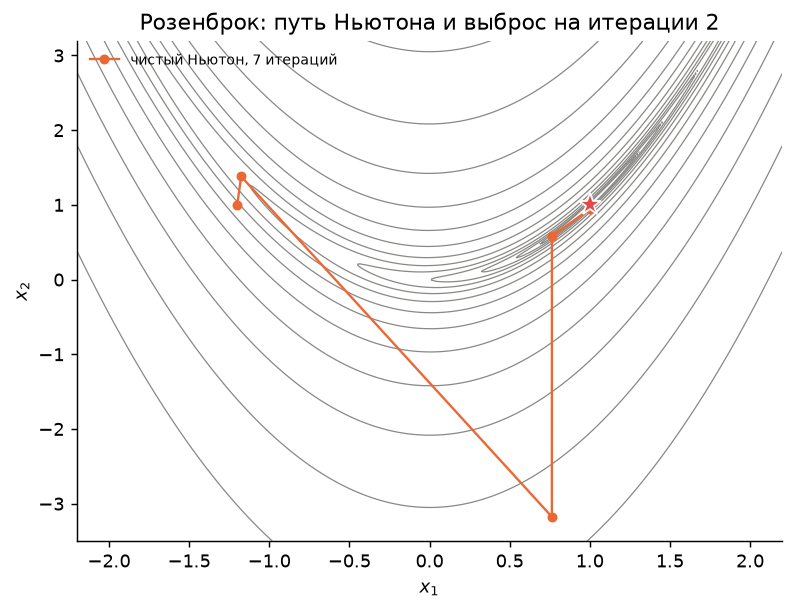

In [4]:
for k in (0, 1, 2):
    print(f"x_{k} = {path_n[k].round(3)}: собственные числа гессиана {np.linalg.eigvalsh(rosen_hess(path_n[k])).round(2)}")
x = np.array([-1.06, 1.18]); g = rosen_grad(x); p = np.linalg.solve(rosen_hess(x), -g)
print(f"точка {x}: det H = {np.linalg.det(rosen_hess(x)):.0f} < 0,  g^T p = {g @ p:+.3f}  -> шаг Ньютона идёт ВВЕРХ")
plot_rosen_path([path_n], ["чистый Ньютон, 7 итераций"]).set_title("Розенброк: путь Ньютона и выброс на итерации 2"); plt.show()

**Шаг 4. Демпфирование.** Добавляем к шагу Ньютона backtracking по Армихо из лекции 4 — три строки. Если направление не спуск ($g^\top p\ge0$), регуляризуем $H+\tau I$. В конспекте — $22$ итерации, $f$ убывает на каждом шаге, выброса нет.

демпфированный Ньютон: 22 итераций (в конспекте 22);  f убывает монотонно: True;  наибольшая ошибка по пути 2.21 (у чистого 4.18)


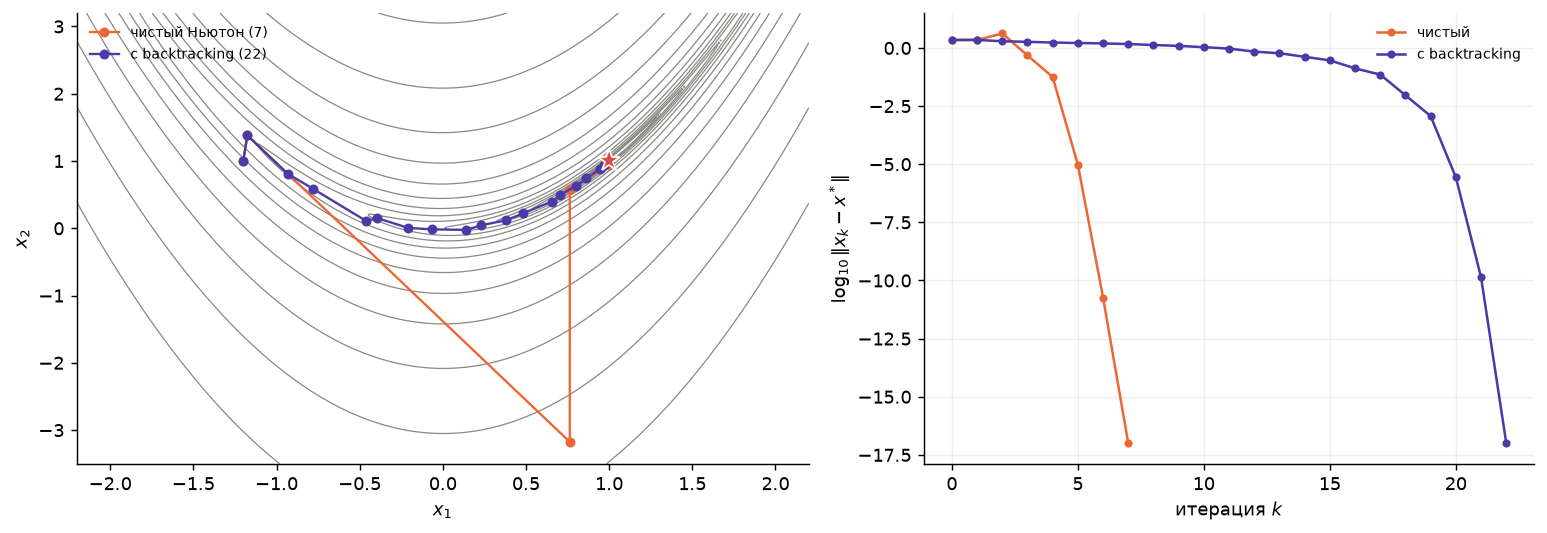

In [5]:
def my_newton_damped(f, grad, hess, x0, tol=1e-10, maxit=200, c=1e-4):
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        H = hess(x); p = np.linalg.solve(H, -g)
        if g @ p >= 0:                                            # не спуск -> сдвигаем собственные числа
            p = np.linalg.solve(H + (abs(np.linalg.eigvalsh(H)[0]) + 1e-3) * np.eye(len(x)), -g)
        a, fx = 1.0, f(x)
        while f(x + a * p) > fx + c * a * (g @ p):                # Армихо: делим шаг пополам
            a /= 2
        x = x + a * p; path.append(x.copy())
    return x, maxit, np.array(path)


x_d, k_d, path_d = my_newton_damped(rosen, rosen_grad, rosen_hess, X0_ROSEN)
f_path = np.array([rosen(v) for v in path_d])
print(f"демпфированный Ньютон: {k_d} итераций (в конспекте 22);  f убывает монотонно: {np.all(np.diff(f_path) < 0)};  наибольшая ошибка по пути {np.linalg.norm(path_d - 1, axis=1).max():.2f} (у чистого 4.18)")
x_ref, k_ref, _ = newton_damped(rosen, rosen_grad, rosen_hess, X0_ROSEN)
assert k_d == k_ref == 22
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.2, 1]})
plot_rosen_path([path_n, path_d], ["чистый Ньютон (7)", "с backtracking (22)"], ax=ax1)
plot_errors([err_n, np.linalg.norm(path_d - 1, axis=1)], ["чистый", "с backtracking"], ax=ax2); plt.tight_layout(); plt.show()

## Часть 2. BFGS с нуля и Гаусс–Ньютон

**Шаг 5. Секущее уравнение руками (упражнение 11.5).** $f=\tfrac12(x_1^2+50x_2^2)$, $x_0=(50,1)$, $H_0=I$, точный шаг $\alpha=\lVert g\rVert^2/g^\top Qg$ на первом шаге и $\alpha=-g^\top p/p^\top Qp$ дальше. Считаем $s_0$, $y_0=Qs_0$, обновляем $H$ по формуле BFGS и проверяем $H_1y_0=s_0$. Второе обновление должно дать $H_2=Q^{-1}=\operatorname{diag}(1,0.02)$ и $x_2=0$.

In [6]:
def bfgs_update(H, s, y):
    """Обновление обратного гессиана: H_{k+1} = (I - rho s y^T) H (I - rho y s^T) + rho s s^T."""
    rho = 1.0 / (s @ y); I = np.eye(len(s))
    return (I - rho * np.outer(s, y)) @ H @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)


Q = np.diag([1.0, 50.0]); x = np.array([50.0, 1.0]); H = np.eye(2)
for k in range(2):
    g = Q @ x; p = -H @ g; a = -(g @ p) / (p @ Q @ p)             # точный шаг на квадратичной
    s = a * p; x_new = x + s; y = Q @ x_new - g
    print(f"шаг {k}: alpha = {a:.4f}  s = {s.round(3)}  y = {y.round(3)}  s^T y = {s @ y:.2f} > 0")
    H = bfgs_update(H, s, y); x = x_new
    print(f"        H_{k + 1} = {np.array2string(H, precision=4, suppress_small=True).replace(chr(10), ' ')}   секущее уравнение H y = s: {np.allclose(H @ y, s)}")
print("x_2 =", x.round(10), "   H_2 == Q^{-1}:", np.allclose(H, np.linalg.inv(Q)), "  (спуск с точным шагом на этой задаче — 567 итераций, лекция 4)")
assert np.allclose(H, np.linalg.inv(Q)) and np.allclose(x, 0, atol=1e-9)

шаг 0: alpha = 0.0392  s = [-1.961 -1.961]  y = [ -1.961 -98.039]  s^T y = 196.08 > 0
        H_1 = [[ 1.9419 -0.0188]  [-0.0188  0.0204]]   секущее уравнение H y = s: True
шаг 1: alpha = 0.5100  s = [-48.039   0.961]  y = [-48.039  48.039]  s^T y = 2353.92 > 0
        H_2 = [[1.   0.  ]  [0.   0.02]]   секущее уравнение H y = s: True
x_2 = [-0.  0.]    H_2 == Q^{-1}: True   (спуск с точным шагом на этой задаче — 567 итераций, лекция 4)


**Шаг 6. BFGS с нуля — пятнадцать строк.** Цикл: направление $p=-Hg$, backtracking по Армихо, пара $(s,y)$, обновление (если $s^\top y>0$). На Розенброке из $(-1.2,1)$ в конспекте — $34$ итерации и $54$ вычисления $f$; `minimize(method="BFGS")` — $33$ и $40$. Хвост отношений $\lVert e_{k+1}\rVert/\lVert e_k\rVert$ стремится к нулю, но не квадратично.

In [7]:
def my_bfgs(f, grad, x0, tol=1e-6, maxit=10_000, c=1e-4):
    x = np.asarray(x0, float).copy(); H = np.eye(len(x)); g = grad(x); path = [x.copy()]; nfev = 1
    for k in range(maxit):
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path), nfev
        p = -H @ g                                                # квази-ньютоновское направление
        a, fx = 1.0, f(x)
        while f(x + a * p) > fx + c * a * (g @ p):                # Армихо
            a /= 2; nfev += 1
        nfev += 1
        s = a * p; x_new = x + s; g_new = grad(x_new); y = g_new - g
        if s @ y > 1e-12:                                         # условие кривизны
            H = bfgs_update(H, s, y)
        x, g = x_new, g_new; path.append(x.copy())
    return x, maxit, np.array(path), nfev


x_b, k_b, path_b, nfev_b = my_bfgs(rosen, rosen_grad, X0_ROSEN)
err_b = np.linalg.norm(path_b - 1, axis=1)
print(f"свой BFGS:  {k_b} итераций, {nfev_b} вычислений f (в конспекте 34 и 54),  x = {x_b.round(7)}")
r = minimize(rosen, X0_ROSEN, jac=rosen_grad, method="BFGS", options={"gtol": 1e-6})
print(f"scipy BFGS: {r.nit} итераций, {r.nfev} вычислений f (в конспекте 33 и 40)")
print("хвост |e_(k+1)|/|e_k|:", np.array2string(err_b[-5:] / err_b[-6:-1], precision=4))
x_ref, k_ref, _, nfev_ref = bfgs(rosen, rosen_grad, X0_ROSEN)
assert k_b == k_ref == 34 and nfev_b == nfev_ref == 54

свой BFGS:  34 итераций, 54 вычислений f (в конспекте 34 и 54),  x = [1. 1.]
scipy BFGS: 33 итераций, 40 вычислений f (в конспекте 33 и 40)
хвост |e_(k+1)|/|e_k|: [0.1422 0.3047 0.0159 0.0322 0.0137]


**Шаг 7. Соревнование: из какого старта BFGS сойдётся быстрее всех?** Каждый выбирает старт в $[-2,2]\times[-1,3]$ и записывает прогноз числа итераций; потом запускаем. Для разогрева — сетка стартов и карта числа итераций. Победитель — наименьшее число итераций при честных параметрах (tol $10^{-6}$, те же $c$ и backtracking).

из (-1.2, 1.0): 34 итераций, 54 вычислений f, пришли в [1. 1.]


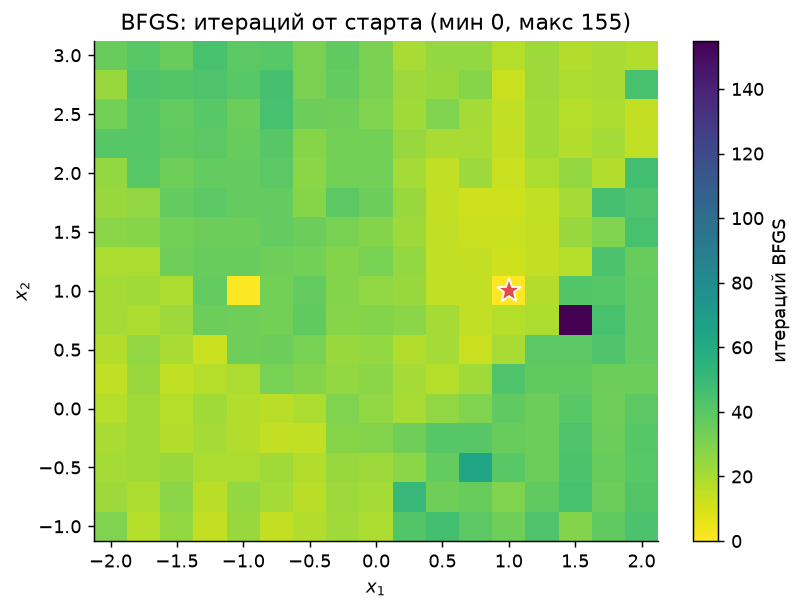

In [8]:
MY_START = (-1.2, 1.0)        # <- впишите свой старт и прогноз числа итераций
x_my, k_my, path_my, nfev_my = my_bfgs(rosen, rosen_grad, MY_START)
print(f"из {MY_START}: {k_my} итераций, {nfev_my} вычислений f, пришли в {x_my.round(6)}")

xs, ys = np.linspace(-2, 2, 17), np.linspace(-1, 3, 17)
iters = np.array([[my_bfgs(rosen, rosen_grad, (a, b_))[1] for a in xs] for b_ in ys])
plt.figure(figsize=(7, 5)); plt.pcolormesh(xs, ys, iters, cmap="viridis_r", shading="nearest"); plt.colorbar(label="итераций BFGS")
plt.plot(1, 1, "*", color=RED, ms=14, mec="white"); plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title(f"BFGS: итераций от старта (мин {iters.min()}, макс {iters.max()})"); plt.grid(False); plt.show()

**Шаг 8. Гаусс–Ньютон на синусе из ДЗ 2 (упражнение 11.7).** Данные те же, что в ДЗ (`default_rng(2026)`), модель $x_1\sin(x_2t+x_3)$. Шаг Гаусса–Ньютона — линейный МНК `lstsq(J, -r)`: без единой второй производной. Из $(1,3,0)$ в конспекте — $7$ итераций к $f^\ast=1.1393$; спуск — $731$; а чистый Ньютон с полным гессианом сходится к точке с $x_1=0$ — нулевой амплитуде, $f\approx64$. Вопрос залу перед запуском: *почему Гаусс–Ньютон не может прийти в такую точку?* (Ответ: $J^\top J\succeq0$, его шаг — всегда спуск, а $f$ при $x_1=0$ больше, чем в старте.)

Гаусс–Ньютон: 7 итераций (в конспекте 7), x = [2.1014 2.9967 0.7003], f = 1.1393
спуск:        731 итераций (в конспекте 731), f = 1.1393
Ньютон:       9 итераций, x = [-0.      3.8658 -6.4737], f = 64.4  <- стационарная точка с нулевой амплитудой


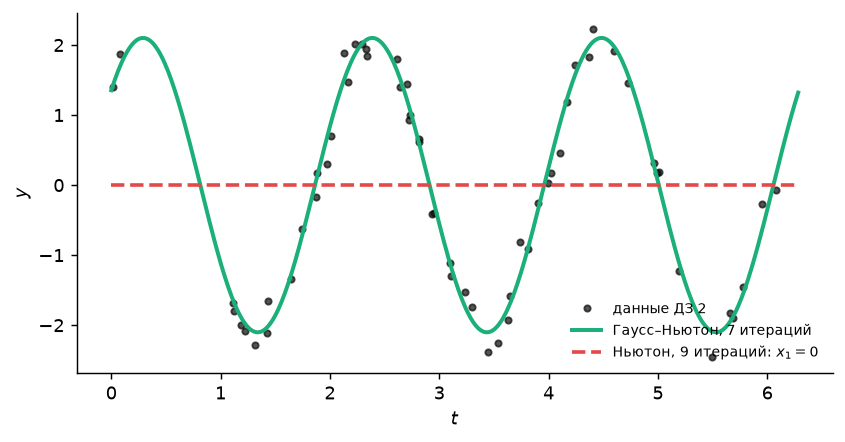

In [9]:
t, y, starts = sine_data()
resid, jac, f_s, grad_s, hess_s = sine_problem(t, y)


def my_gauss_newton(resid, jac, x0, tol=1e-6, maxit=100):
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        r, J = resid(x), jac(x)
        if np.linalg.norm(J.T @ r) <= tol:
            return x, k, np.array(path)
        x = x + np.linalg.lstsq(J, -r, rcond=None)[0]             # линеаризуем невязку -> линейный МНК
        path.append(x.copy())
    return x, maxit, np.array(path)


x_gn, k_gn, path_gn = my_gauss_newton(resid, jac, X0_SINE)
x_gd, k_gd, _ = gd(f_s, grad_s, X0_SINE)
x_nw, k_nw, _ = my_newton(grad_s, hess_s, X0_SINE, tol=1e-6)
print(f"Гаусс–Ньютон: {k_gn} итераций (в конспекте 7), x = {x_gn.round(4)}, f = {f_s(x_gn):.4f}")
print(f"спуск:        {k_gd} итераций (в конспекте 731), f = {f_s(x_gd):.4f}")
print(f"Ньютон:       {k_nw} итераций, x = {x_nw.round(4)}, f = {f_s(x_nw):.1f}  <- стационарная точка с нулевой амплитудой")
x_ref, k_ref, _ = gauss_newton(resid, jac, X0_SINE)
assert k_gn == k_ref == 7 and np.allclose(x_gn, x_ref)
tt = np.linspace(0, 2 * np.pi, 400)
plt.figure(figsize=(7.5, 3.6)); plt.plot(t, y, "o", ms=3.5, color=INK, alpha=0.7, label="данные ДЗ 2")
plt.plot(tt, x_gn[0] * np.sin(x_gn[1] * tt + x_gn[2]), color=AQUA, lw=2.2, label=f"Гаусс–Ньютон, {k_gn} итераций")
plt.plot(tt, x_nw[0] * np.sin(x_nw[1] * tt + x_nw[2]), "--", color=RED, lw=2, label=f"Ньютон, {k_nw} итераций: $x_1=0$")
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.legend(fontsize=8); plt.grid(False); plt.show()

## Итог

- Шаг Ньютона — минимум квадратичной модели: десять строк кода, $7$ итераций, цифры удваиваются; но вдали от минимума модель врёт — выброс на итерации 2, а на седловой модели шаг может идти вверх.
- Backtracking превращает Ньютона в метод спуска: $22$ итерации, $f$ убывает монотонно.
- Секущее уравнение $B_{k+1}s_k=y_k$ измеряет кривизну разностью градиентов; BFGS хранит её в $H_k$: на квадратичной $2\times2$ — два обновления и $H_2=Q^{-1}$, на Розенброке — $34$ итерации без единой второй производной, SciPy — $33$.
- Гаусс–Ньютон — линейный МНК на каждом шаге: $7$ итераций против $731$ у спуска, и он не может уйти в стационарную точку с $x_1=0$, куда ушёл Ньютон.
- `Newton-CG` сделал $85$ итераций: внутри система решается приближённо — об этом и о правильном линейном поиске лекция 6.

Дома: 11.0–11.4, 11.6, 11.8–11.10 из конспекта; 11.5 и 11.7 — повторение этого семинара. ДЗ 3 — те же методы на тех же задачах, срок 21 октября.